
# 🧠 CSE411 Computer Vision: Principles and Processes  
## **Project: Plant Disease Detection (Tomato Leaf Classification)**  
### **Group 8**

---
**Objective:** Detect tomato leaf diseases using the PlantVillage dataset through a comprehensive preprocessing pipeline.  
This notebook refines images before training a deep learning classifier by applying augmentation, denoising, contrast enhancement, segmentation, and edge highlighting.


In [2]:

# Import core libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define constants and directories
IMG_SIZE = 256
RAW_DIR = os.path.join(os.getcwd(), "Plant_leave_diseases_dataset_without_augmentation")
AUG_DIR = "augmented_dataset/"
SEG_DIR = "segmented_dataset/"
TARGET_COUNT = 3000

# Create directories if not present
os.makedirs(AUG_DIR, exist_ok=True)
os.makedirs(SEG_DIR, exist_ok=True)



## 🧩 Step 1: Data Augmentation  
Artificially expand and diversify dataset to simulate real-world conditions.  
Techniques include: **Rotation, Flips, Translation, Shear, Cropping.**


In [ ]:
# Resize image to target size
def preprocess(image):
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE))

In [ ]:

# Rotate randomly within ±angle range
def random_rotation(image, angle=45):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), np.random.uniform(-angle, angle), 1)
    return cv2.warpAffine(image, M, (w, h))

In [ ]:
# Translate (shift) image randomly
def random_translation(image, max_shift=0.2):
    h, w = image.shape[:2]
    tx, ty = np.random.uniform(-max_shift, max_shift, 2) * np.array([w, h])
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, M, (w, h))

In [ ]:


# Apply random shear
def random_shear(image, s=15):
    h, w = image.shape[:2]
    pts1 = np.float32([[5,5],[w-5,5],[5,h-5]])
    pts2 = np.float32([[5+np.random.randint(-s,s),5],
                       [w-5+np.random.randint(-s,s),5],
                       [5,h-5+np.random.randint(-s,s)]])
    M = cv2.getAffineTransform(pts1, pts2)
    return cv2.warpAffine(image, M, (w,h))

In [ ]:
# Crop random section and resize
def random_crop(image, scale=0.8):
    h, w = image.shape[:2]
    nh, nw = int(h*scale), int(w*scale)
    top, left = np.random.randint(0, h-nh), np.random.randint(0, w-nw)
    return cv2.resize(image[top:top+nh, left:left+nw], (w,h))

In [ ]:
# Randomly choose one augmentation
def augment_image(image):
    ops = [random_rotation, lambda x: cv2.flip(x,1),
           lambda x: cv2.flip(x,0), random_translation,
           random_shear, random_crop]
    return np.random.choice(ops)(image)


In [4]:

# Perform augmentation for each class
for cls in os.listdir(RAW_DIR):
    src = os.path.join(RAW_DIR, cls)
    dst = os.path.join(AUG_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    imgs = [f for f in os.listdir(src) if f.lower().endswith(('jpg','png','jpeg'))]
    count = len(imgs)
    print(f"\nProcessing class: {cls} | {count}/{TARGET_COUNT}")

    # Resize and copy originals
    for name in imgs:
        img = cv2.imread(os.path.join(src, name))
        if img is not None:
            cv2.imwrite(os.path.join(dst, name), preprocess(img))

    # Generate augmented images until target count reached
    pbar = tqdm(total=TARGET_COUNT-count, desc=f"Augmenting {cls}")
    i = 0
    while count < TARGET_COUNT:
        img = cv2.imread(os.path.join(src, imgs[i % len(imgs)]))
        if img is None:
            i += 1
            continue
        aug_img = augment_image(img)
        cv2.imwrite(os.path.join(dst, f"{cls}_{count}.jpg"), aug_img)
        count += 1
        i += 1
        pbar.update(1)
    pbar.close()



Processing class: Tomato_Bacterial_spot | 2127/3000


Augmenting Tomato_Bacterial_spot: 100%|██████████| 873/873 [00:05<00:00, 152.53it/s]



Processing class: Tomato_Early_blight | 1000/3000


Augmenting Tomato_Early_blight: 100%|██████████| 2000/2000 [00:10<00:00, 188.14it/s]



Processing class: Tomato_healthy | 1591/3000


...

Augmenting Tomato__Target_Spot: 100%|██████████| 1596/1596 [00:09<00:00, 173.47it/s]



Processing class: Tomato__Tomato_mosaic_virus | 373/3000


Augmenting Tomato__Tomato_mosaic_virus: 100%|██████████| 2627/2627 [00:14<00:00, 178.98it/s]



Processing class: Tomato__Tomato_YellowLeaf__Curl_Virus | 3208/3000


Augmenting Tomato__Tomato_YellowLeaf__Curl_Virus: 0it [00:00, ?it/s]



## 🧩 Step 2: Noise Reduction  
Reduce background noise and preserve important edges using **Bilateral Filtering.**


In [3]:

# Apply bilateral filter for noise reduction
def noise_reduction(image):
    return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

# Apply to all augmented images
for cls in os.listdir(AUG_DIR):
    path = os.path.join(AUG_DIR, cls)
    if not os.path.isdir(path): continue

    for name in tqdm(os.listdir(path), desc=f"Filtering {cls}"):
        if name.lower().endswith(('jpg','png','jpeg')):
            img_path = os.path.join(path, name)
            img = cv2.imread(img_path)
            if img is not None:
                clean = noise_reduction(img)
                cv2.imwrite(img_path, clean)


Filtering PlantVillage: 0it [00:00, ?it/s]


Filtering Tomato_Septoria_leaf_spot: 100%|██████████| 3000/3000 [02:03<00:00, 24.31it/s]
Filtering Tomato_Spider_mites_Two_spotted_spider_mite: 100%|██████████| 3000/3000 [02:10<00:00, 22.92it/s]
Filtering Tomato__Tomato_YellowLeaf__Curl_Virus: 100%|██████████| 3208/3208 [02:08<00:00, 24.97it/s]



## 🧩 Step 3: Contrast Enhancement (CLAHE)  
Enhance visual contrast locally by applying **CLAHE** to the L-channel in LAB color space.


In [4]:

# Apply CLAHE enhancement on each image
for cls in os.listdir(AUG_DIR):
    path = os.path.join(AUG_DIR, cls)
    if not os.path.isdir(path): continue

    for name in tqdm(os.listdir(path), desc=f"Enhancing {cls}"):
        if name.lower().endswith(('jpg','png','jpeg')):
            img = cv2.imread(os.path.join(path, name))
            if img is None: continue

            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(2.0, (8,8))
            l_eq = clahe.apply(l)
            merged = cv2.merge((l_eq,a,b))
            img_eq = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
            cv2.imwrite(os.path.join(path, name), img_eq)


Enhancing PlantVillage: 0it [00:00, ?it/s]
Enhancing Tomato_Septoria_leaf_spot: 100%|██████████| 3000/3000 [01:19<00:00, 37.76it/s]
Enhancing Tomato_Spider_mites_Two_spotted_spider_mite: 100%|██████████| 3000/3000 [01:18<00:00, 38.30it/s]
Enhancing Tomato__Tomato_YellowLeaf__Curl_Virus: 100%|██████████| 3208/3208 [01:26<00:00, 37.14it/s]



## 🧩 Step 4: Leaf Segmentation (HSV Masking)  
Isolate the green leaf region and remove the background to ensure the model focuses only on the leaf.


In [5]:

# Create mask for green hue range
def segment_leaf(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower = np.array([25, 40, 40])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    return cv2.bitwise_and(image, image, mask=mask)

# Apply segmentation to all images
for cls in os.listdir(AUG_DIR):
    src = os.path.join(AUG_DIR, cls)
    dst = os.path.join(SEG_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    for name in tqdm(os.listdir(src), desc=f"Segmenting {cls}"):
        if name.lower().endswith(('jpg','png','jpeg')):
            img = cv2.imread(os.path.join(src, name))
            if img is not None:
                seg = segment_leaf(img)
                cv2.imwrite(os.path.join(dst, name), seg)


Segmenting PlantVillage: 0it [00:00, ?it/s]
Segmenting Tomato_Septoria_leaf_spot: 100%|██████████| 3000/3000 [01:15<00:00, 39.65it/s]
Segmenting Tomato_Spider_mites_Two_spotted_spider_mite: 100%|██████████| 3000/3000 [01:16<00:00, 39.34it/s]
Segmenting Tomato__Tomato_YellowLeaf__Curl_Virus: 100%|██████████| 3208/3208 [01:07<00:00, 47.87it/s]



## 🧩 Step 5: Edge Detection
Highlight disease boundaries and vein structures to emphasize texture for the CNN.


In [6]:

# Apply edge detection and enhancement
for cls in os.listdir(SEG_DIR):
    path = os.path.join(SEG_DIR, cls)
    if not os.path.isdir(path): continue

    for name in tqdm(os.listdir(path), desc=f"Edges {cls}"):
        if name.lower().endswith(('jpg','png','jpeg')):
            img_path = os.path.join(path, name)
            img = cv2.imread(img_path)
            if img is None: continue

            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            L, A, B = cv2.split(lab)
            L_blur = cv2.bilateralFilter(L, 9, 75, 75)

            # Detect edges using dual Canny
            edge1 = cv2.Canny(L_blur, 80, 100)
            edge2 = cv2.Canny(L_blur, 40, 50)
            edges = cv2.bitwise_or(edge1, edge2)

            # Morphological closing to connect broken lines
            edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE,
                                     cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7)))

            # Keep largest contour
            contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                mask = np.zeros_like(edges)
                cv2.drawContours(mask, [max(contours, key=cv2.contourArea)], -1, 255, 2)
                edges = mask

            # Blend edges into original L-channel
            canny_L = cv2.addWeighted(L, 0.7, edges, 1, 0)
            enhanced = cv2.cvtColor(cv2.merge([canny_L, A, B]), cv2.COLOR_LAB2BGR)
            cv2.imwrite(img_path, enhanced)


Edges PlantVillage: 0it [00:00, ?it/s]
Edges Tomato_Septoria_leaf_spot: 100%|██████████| 3000/3000 [01:47<00:00, 27.96it/s]
Edges Tomato_Spider_mites_Two_spotted_spider_mite: 100%|██████████| 3000/3000 [01:45<00:00, 28.46it/s]
Edges Tomato__Tomato_YellowLeaf__Curl_Virus: 100%|██████████| 3208/3208 [01:43<00:00, 31.07it/s]



## 🧩 Step 6: Visualization  
Display an example processed image to verify preprocessing results.


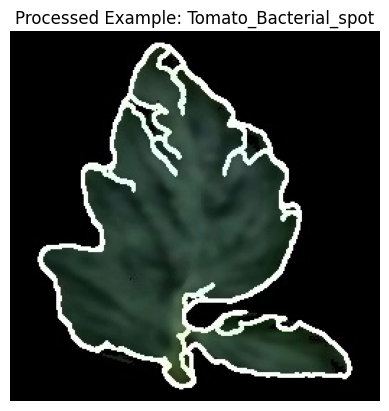

In [4]:

cls_sample = os.listdir(SEG_DIR)[0]
img_sample = os.listdir(os.path.join(SEG_DIR, cls_sample))[0]
sample_path = os.path.join(SEG_DIR, cls_sample, img_sample)

sample = cv2.imread(sample_path)
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f"Processed Example: {cls_sample}")
plt.axis('off')
plt.show()



## ✅ Completion  
All preprocessing stages successfully executed.  
The dataset in `segmented_dataset/` is now optimized for CNN training.


In [ ]:

print("✅ Preprocessing complete. Images saved to 'segmented_dataset/'")
